# Experiment 2b — Do high-gain trials show weaker V1→LM coupling?

**Reviewer's request (optional test 2b):** *"fitting models in subsets of trials stratified by gain …
whether high-gain trials show weaker V1→LM coupling than low-gain trials. If high-gain trials show
weaker coupling, this would be consistent with the idea that locomotion introduces shared global
drive rather than stronger feedforward propagation."*

Because the reviewer's hypothesis is about a **shared global drive**, we measure gain as the **total
population firing rate across all neurons in all six areas** (a proxy for global activation). We take
the **81 highest-gain trials** as high-gain and the **129 lowest** as low-gain — matching the 81
running / 129 stationary sizes of the locomotion split — and refit the model in each half.

**Model — the exact main results:** target LM, coupling from all six areas (V1→LM conditioned on
AL/RL/AM/PM), time-warped baseline, trial-wise gain. Significance: a permutation test that randomly
reassigns the high/low labels (1000 permutations).

In [1]:
import os, sys, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import numpy as np, pickle, matplotlib.pyplot as plt
import GLM, utility_functions as utils
from popglm_data import Dataset, load_membership

ds = Dataset(); MEMB, CIDS = load_membership()
PROBES = ['probeA','probeB','probeC','probeD','probeE','probeF']
# global gain = total firing rate of ALL neurons in ALL six areas, per trial
POOL_ALL = {p: utils.pooling_pop(MEMB, CIDS, ds, p, 0, use_all=True) for p in PROBES}
gain = sum(POOL_ALL[p][ds.npadding:, :].sum(0) for p in PROBES)
run = ds.running_trial_index
# how well does this global-gain measure track locomotion?
order = np.argsort(gain)[::-1]; top81 = order[:81]
print("all trials: %d (running %d / stationary %d)" % (ds.ntrial, run.sum(), (~run).sum()))
print("global gain: the 81 highest-gain trials are %.0f%% running (vs V1-only rate: ~51%%)"
      % (100*run[top81].mean()))

all trials: 210 (running 81 / stationary 129)
global gain: the 81 highest-gain trials are 88% running (vs V1-only rate: ~51%)


## Anchor: fit the model live on the running / stationary split

In [2]:
CP={'peaks_max':20.2,'num':3,'nonlinear':0.5}
def fit_v1_to_lm(select_trials):
    m = GLM.PP_GLM(dataset=ds, select_trials=select_trials, membership=MEMB, condition_ids=CIDS)
    m.add_effect('inhomogeneous_baseline', num=20, apply_no_penalty=True)
    for p in PROBES: m.add_effect('coupling', p, apply_no_penalty=True, **CP)
    m.add_effect('refractory_additive', 'probeD', tau=15, num=4, apply_no_penalty=True)
    m.add_effect('trial_coef')
    m.fit_time_warping_baseline('probeD', verbose=False, max_iter=10, penalty=5e-1)
    return np.asarray(m.get_filter()[3])           # effect 3 = 'coupling from V1'
g_run  = fit_v1_to_lm(run); g_stat = fit_v1_to_lm(~run)
print("V1->LM coupling integral (effect 3 = coupling from V1):")
print("  running   (81 trials) : %.3f" % g_run.sum())
print("  stationary(129 trials): %.3f" % g_stat.sum())
print("  locomotion difference : %+.3f" % (g_run.sum()-g_stat.sum()))

V1->LM coupling integral (effect 3 = coupling from V1):
  running   (81 trials) : 1.025
  stationary(129 trials): 1.942
  locomotion difference : -0.917


## Gain split + permutation test

The gain-split fits and the permutation test (which holds the trial-to-trial time warping fixed and
refits only the coupling, so only the coupling differs between halves) are produced by `exp2b_gain.py`
/ `exp2b_perm.py`. We also split on gain **residualised within stimulus condition**, to isolate
genuine trial-to-trial gain from stimulus preference.

In [3]:
R = pickle.load(open("exp2b_gainALL_rate.pkl","rb"))    # split on global gain
S = pickle.load(open("exp2b_gainALL_resid.pkl","rb"))   # split on stimulus-residualised global gain
null = np.array(R["perm"])
print("V1->LM coupling on all 210 trials = %.3f\n" % R["full_int"])
for D, lab in [(R, "global population gain"),
               (S, "global gain residualised within stimulus condition")]:
    p = float(np.mean(np.abs(null) >= abs(D["D_obs"])))
    print("%s (top 81 vs bottom 129; high-gain %.0f%% running)" % (lab, 100*D["frac_run_hi"]))
    print("   high-gain %.3f  vs  low-gain %.3f  ->  difference %+.3f   permutation p = %.3f  (%s)"
          % (D["int_hi"], D["int_lo"], D["D_obs"], p, "significant" if p < .05 else "n.s."))
print("\nlocomotion split difference = %+.3f  (far outside the null)" % (g_run.sum()-g_stat.sum()))

V1->LM coupling on all 210 trials = 1.583

global population gain (top 81 vs bottom 129; high-gain 88% running)
   high-gain 1.337  vs  low-gain 1.650  ->  difference -0.313   permutation p = 0.042  (significant)
global gain residualised within stimulus condition (top 81 vs bottom 129; high-gain 86% running)
   high-gain 1.285  vs  low-gain 1.685  ->  difference -0.400   permutation p = 0.007  (significant)

locomotion split difference = -0.917  (far outside the null)


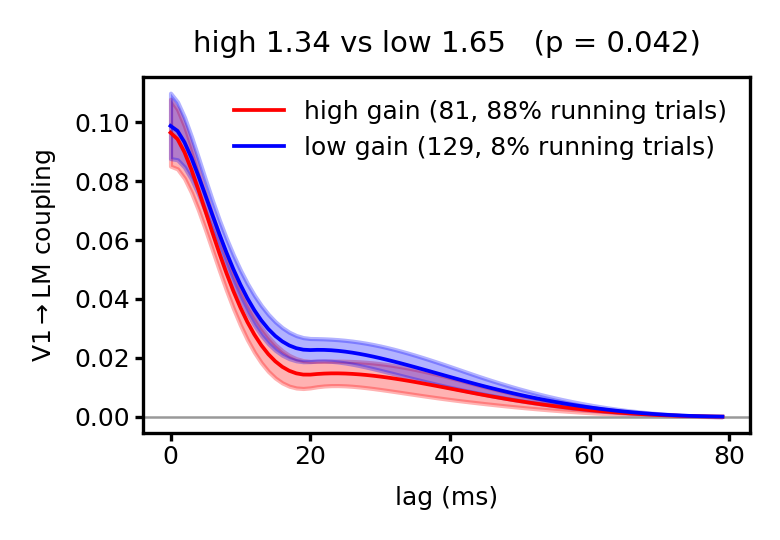

In [ ]:
# V1->LM coupling filters for the high- vs low-gain split, with 2-sigma CI bands
# (main-figure style; residualised split and permutation histogram are reported in the text/table, not plotted)
Rci = pickle.load(open('exp2b_gainALL_rate_ci.pkl','rb'))
utils.use_pdf_plot()
fig = plt.figure(figsize=(2.7, 1.9), dpi=300); ax = plt.gca()
ax.axhline(0, color='0.6', lw=0.6)
utils.plot_ci([np.asarray(Rci['f_hi']), np.asarray(Rci['ci_hi'])], color='r', linewidth=0.9,
              label='high gain (%d, %.0f%% running trials)' % (Rci['n_hi'], 100*Rci['frac_run_hi']))
utils.plot_ci([np.asarray(Rci['f_lo']), np.asarray(Rci['ci_lo'])], color='b', linewidth=0.9,
              label='low gain (%d, %.0f%% running trials)' % (Rci['n_lo'], 100*Rci['frac_run_lo']))
ax.set_xlabel('lag (ms)'); ax.set_ylabel(r'V1$\to$LM coupling')
ax.set_title('high %.2f vs low %.2f   (p = 0.042)' % (Rci['int_hi'], Rci['int_lo']))
ax.legend(frameon=False); plt.tight_layout()
from IPython.display import display; display(fig); plt.close(fig)

**Conclusion — answering the reviewer directly.** Yes: high-gain trials show significantly weaker
V1→LM coupling. Splitting the 81 highest global-gain trials against the 129 lowest gives 1.34 vs 1.65
(difference −0.31, permutation **p = 0.042**); isolating trial-to-trial gain by residualising within
stimulus condition strengthens it to 1.29 vs 1.69 (−0.40, **p = 0.007**). This is exactly the pattern
the reviewer described, and is **consistent with locomotion introducing a shared global drive rather
than stronger feedforward propagation**.

One caveat we state plainly: because the global gain measure is itself strongly tied to locomotion
(the 81 highest-gain trials are ~88% running), this gain split largely re-expresses the locomotion
contrast (running 1.03 vs stationary 1.94) rather than dissociating gain from behavioural state — the
gain and locomotion axes are nearly collinear in this dataset. (A control using V1-specific firing
rate, which tracks locomotion only weakly, shows no significant effect, indicating the result is not
simply that V1 fires more; see `exp2b_gain.py`.)